In [133]:
import numpy as np
import torch 
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from anastruct import SystemElements
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt 
import openpyxl as pxl
import torch.nn.functional as F
import os
import re
import csv
from datetime import datetime
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics  import mean_absolute_error, r2_score


In [134]:
#General Parameters for improve results 

alpha =0.5   # Bell curve coefficient 
dropout = 0.0       #deactivation of neuron = for now 0 , little data set
Lambda = 0.5 # how much to weight the loss of physics
epochs = 700
seed=42
patience = 100        
batch_size=32

In [135]:
#import Excel Data

notebook_dir = os.getcwd() #where is file located
file_path =os.path.join(notebook_dir,'Data','MLPARTA.xlsx') #Read the file 

#read Excel with formulas using Openpyxl

wb = pxl.load_workbook(file_path) #create local data
ws = wb.active 

headers = [ws.cell(1,col).value for col in range (1,ws.max_column+1)]

#Convert excel language to python

#extract names
letter_to_name = {}
for col in range(1,ws.max_column+1):
    letter = pxl.utils.get_column_letter(col)
    letter_to_name[letter] =headers[col-1]

def excel_to_python(formula, letter_to_name):
    result = formula
    result = result.lstrip('=')
    result = result.replace('$', '')
    result = re.sub(r'\bPI\(\)', 'np.pi', result)

    def replace_ref(match):
        letter = match.group(1)
        if letter in letter_to_name:
            name = letter_to_name[letter]
            return f"df['{name}']"
        return match.group(0)

    result = re.sub(r'\b([A-Z]{1,3})(\d+)\b', replace_ref, result)
    #extract the formulas
    excel_to_np = {
        'SIN'   : 'np.sin',
        'COS'   : 'np.cos',
        'TAN'   : 'np.tan',
        'ATAN'  : 'np.arctan',
        'ATAN2' : 'np.arctan2',
        'ASIN'  : 'np.arcsin',
        'ACOS'  : 'np.arccos',
        'SQRT'  : 'np.sqrt',
        'ABS'   : 'np.abs',
        'EXP'   : 'np.exp',
        'LOG'   : 'np.log',
        'LOG10' : 'np.log10',
        'POWER' : 'np.power',
        'MOD'   : 'np.mod',
        'FLOOR' : 'np.floor',
        'CEIL'  : 'np.ceil',
        'ROUND' : 'np.round',
        'MAX'   : 'np.maximum',
        'MIN'   : 'np.minimum',
        'SUM'   : 'np.sum',
    }

    for excel_fn, np_fn in excel_to_np.items():
        result = re.sub(rf'\b{excel_fn}\b', np_fn, result)

    result = result.replace('^', '**')
    result = result.lstrip('=')

    return result

#create a formula list

formula_list = {}
for col in range(1,ws.max_column+1):
    cell =ws.cell(2,col)
    value = cell.value
    name = headers[col-1]
    if isinstance(value,str) and value.startswith('='):
        formula_list[name]=excel_to_python(value,letter_to_name)

raw_cols = [h for h in headers if h not in formula_list]

#find the values of the data provided in the excel and extract into a dataframe

def compute_features(df,formula_list):
    df = df.copy()
    remaining = dict(formula_list)
    max_passes = len(formula_list)+1
    passes =0 

    while remaining and passes < max_passes:
        passes +=1
        newly_computed=[]
        
        for col_name, expr in remaining.items():
            try:
                df[col_name]=eval(expr)
                newly_computed.append(col_name)
            except Exception:
                pass
        for col in newly_computed:
            del remaining[col]
        if not newly_computed:
            print(f"\n Warning Error Newly Computed")
            break
    return df

#Cleaning of the dataset to optain a final dataset for the training of the model 
wb_data = pxl.load_workbook(file_path, data_only=True)
ws_data = wb_data.active 
data    = [row for row in ws_data.iter_rows(min_row=2, values_only=True)]
df_raw  = pd.DataFrame(data, columns=headers)
df_computed = compute_features(df_raw[raw_cols], formula_list) 
df_training = df_computed.drop(columns=[None], errors='ignore').dropna().reset_index(drop=True) #drops invalid data
print(f"df_training shape: {df_training.shape}")   # should be (100, 28)


df_training shape: (100, 28)


In [136]:
# # Verify 
# # ── 8. Verify against Excel ───────────────────────────────────
# print(f"\n{'='*60}")
# print(f"  Verify — Python vs Excel (row 1)")
# print(f"{'='*60}")
# print(f"{'Column':>15} | {'Excel':>12} | {'Python':>12} | {'Match':>6}")
# print(f"{'-'*60}")

# match_count = 0
# for col in formula_list.keys():
#     if col in df_raw.columns and col in df_computed.columns:
#         excel_val  = df_raw[col].iloc[0]
#         python_val = df_computed[col].iloc[0]
#         if excel_val is not None and not pd.isna(excel_val):
#             match = abs(excel_val - python_val) < 1e-4
#             if match:
#                 match_count += 1
#             print(f"{col:>15} | {excel_val:>12.4f} | {python_val:>12.4f} | "
#                   f"{'✓' if match else '✗':>6}")

# print(f"\n  Matched : {match_count} / {len(formula_list)} columns")
# print(f"{'='*60}")

# # ── 9. Final dataset summary ──────────────────────────────────
# print(f"\n{'='*60}")
# print(f"  FINAL DATASET")
# print(f"{'='*60}")
# print(f"  Shape   : {df_computed.shape}")
# print(f"  Columns : {df_computed.columns.tolist()}")
# print(f"\n{'='*60}")
# print(f"  STATISTICS")
# print(f"{'='*60}")
# print(f"{'Column':>15} | {'Min':>12} | {'Max':>12} | {'Mean':>12}")
# print(f"{'-'*60}")
# for col in df_computed.columns:
#     vals = df_computed[col].dropna()
#     if vals.dtype in [float, int]:
#         print(f"{col:>15} | {vals.min():>12.4f} | "
#               f"{vals.max():>12.4f} | {vals.mean():>12.4f}")
# print(f"{'='*60}")

In [137]:
# # Print formulas 
# print(f"  Formula — {len(formula_list)} columns")
# for col_name, expr in formula_list.items():
#     print(f"\n  Column  : {col_name}")
#     print(f"  Python  : {expr}")


In [138]:
# Define Target Columns 

target_col = ['Ftan_c','Power']
n_output = len(target_col) #save size 
constant_cols={}

def is_constant(series, cv_threshold=0.01):
    std  = series.std()
    mean = series.mean()
    if pd.isna(std) or std == 0:    return True
    if mean == 0 or pd.isna(mean):  return std < 1e-10
    return (std / abs(mean)) < cv_threshold

for col in df_training.columns:
    if col is None or col in target_col:
        continue
    series = df_training[col].dropna()   # guard against empty columns
    if len(series) == 0:
        continue
    if is_constant(series):
        constant_cols[col] = series.iloc[0]

C = df_training[list(constant_cols.keys())].copy()
Y = df_training[target_col].copy()

feature_cols=['L','R','cross_area','Density','F_cl','W_motor','F_PB'] #simulate new condition
for col in df_training.columns:
    if col is None or col in feature_cols:
        continue
    series = df_training[col].dropna()   # guard against empty columns
    if len(series) == 0:
        continue
    if is_constant(series):
        constant_cols[col] = series.iloc[0]

X = df_training[feature_cols].copy()+df_training[list(constant_cols.keys())].copy()

x = torch.tensor(X.values, dtype=torch.float32)
y = torch.tensor(Y.values, dtype=torch.float32)
c = torch.tensor(C.values, dtype=torch.float32)

print(f"  Dataframe check ")

print(f"\n  C — Constants : {C.shape}")
print(f"    {C.columns.tolist()}")
print(f"\n  Y — Target    : {Y.shape}")
print(f"    {Y.columns.tolist()}")
print(f"\n  X — Features  : {X.shape}")
print(f"    {X.columns.tolist()}")

print(f"  x tensor : {x.shape}")
print(f"  y tensor : {y.shape}")
print(f"  c tensor : {c.shape}")
print(f"  NaN in x : {torch.isnan(x).sum().item()}")
print(f"  NaN in y : {torch.isnan(y).sum().item()}")
print(f"  NaN in c : {torch.isnan(c).sum().item()}")


  Dataframe check 

  C — Constants : (100, 5)
    ['F_PB', 'Density', 'W_motor', 'Fx_s', 'Ftotal_s']

  Y — Target    : (100, 2)
    ['Ftan_c', 'Power']

  X — Features  : (100, 9)
    ['Density', 'F_PB', 'F_cl', 'Ftotal_s', 'Fx_s', 'L', 'R', 'W_motor', 'cross_area']
  x tensor : torch.Size([100, 9])
  y tensor : torch.Size([100, 2])
  c tensor : torch.Size([100, 5])
  NaN in x : 600
  NaN in y : 0
  NaN in c : 0


In [139]:
#Parameters

num_workers=0   # cpu (AI Recommended)

class Training(Dataset):

    def __init__(self, x_mix, y_mix, x_orig):
        assert x_mix.shape[0] == y_mix.shape[0] == x_orig.shape[0]
        self.x_mix  = x_mix
        self.y_mix  = y_mix
        self.x_orig = x_orig

    def __len__(self):return self.x_mix.shape[0]
    def __getitem__(self, idx):return (self.x_mix[idx],self.y_mix[idx],self.x_orig[idx],)

class Validation(Dataset):

    def __init__(self,x,y,c):
        assert x.shape[0] == y.shape[0] == c.shape[0]
        self.x = x
        self.y = y
        self.c = c

    def __len__(self):return self.x.shape[0]
    def __getitem__(self, idx): return self.x[idx], self.y[idx], self.c[idx]

def get_dataloaders(train_ds,val_ds,batch_size,num_workers,seed) -> tuple[DataLoader, DataLoader]:
    g = torch.Generator().manual_seed(seed) #shuffle generator

    train_loader = DataLoader(
        train_ds,
        batch_size  = batch_size,
        shuffle     = True,
        drop_last   = True,
        num_workers = num_workers,
        generator   = g, #shuffle
    )
    val_loader = DataLoader(
        val_ds,
        batch_size  = batch_size,
        shuffle     = False,
        drop_last   = False,
        num_workers = num_workers,
    )
    return train_loader, val_loader


In [140]:
#  Training, Test and Validation DataFrames

def split_data(x, y, c, seed, train_frac=0.70, val_frac=0.20):
    torch.manual_seed(seed)
    sorted_idx = torch.argsort(y[:, -1])
    n = len(sorted_idx)

    third = n // 3
    bands = [
        sorted_idx[:third],
        sorted_idx[third:2*third],
        sorted_idx[2*third:]
    ]

    train_idx, val_idx, test_idx = [], [], []

    for band in bands:
        m       = len(band)
        n_train = int(m * train_frac)
        n_val   = int(m * val_frac)

        train_idx.append(band[:n_train])
        val_idx.append(band[n_train:n_train + n_val])
        test_idx.append(band[n_train + n_val:])

    return (
        torch.cat(train_idx),
        torch.cat(val_idx),
        torch.cat(test_idx),
    )

def mixup(x, y, c, alpha=alpha, seed=seed):
    np.random.seed(seed)
    N     = x.size(0)
    lam   = np.random.beta(alpha, alpha, size=N)
    lam   = np.maximum(lam, 1 - lam)
    lam_t = torch.tensor(lam, dtype=torch.float32)
    idx_p = torch.randperm(N)
    lam_x = lam_t.unsqueeze(1)
    lam_y = lam_x if y.dim() == 2 else lam_t
    x_mix = lam_x * x + (1 - lam_x) * x[idx_p]
    y_mix = lam_y * y + (1 - lam_y) * y[idx_p]
    c_mix = lam_x * c + (1 - lam_x) * c[idx_p]
    return x_mix, y_mix, c_mix


train_idx, val_idx, test_idx = split_data(x, y, c, seed=seed)

print(f'  Train : {len(train_idx):>3} samples  ({len(train_idx)/len(x)*100:.0f}%)')
print(f'  Val   : {len(val_idx):>3} samples  ({len(val_idx)/len(x)*100:.0f}%)')
print(f'  Test  : {len(test_idx):>3} samples  ({len(test_idx)/len(x)*100:.0f}%)')
for col_i, col in enumerate(target_col):
    print(f'  {col} range — '
          f'Train [{y[train_idx,col_i].min():.2f}, {y[train_idx,col_i].max():.2f}]  '
          f'Val [{y[val_idx,col_i].min():.2f}, {y[val_idx,col_i].max():.2f}]  '
          f'Test [{y[test_idx,col_i].min():.2f}, {y[test_idx,col_i].max():.2f}]')

  Train :  69 samples  (69%)
  Val   :  18 samples  (18%)
  Test  :  13 samples  (13%)
  Ftan_c range — Train [52.46, 140.19]  Val [62.20, 141.13]  Test [87.55, 138.74]
  Power range — Train [10.77, 67.43]  Val [32.27, 71.79]  Test [36.82, 79.60]


In [141]:
class Sohoite(nn.Module):
    def __init__(self, input_dim, n_outputs=2, dropout=dropout):
        super().__init__()
        def block(in_f, out_f):
            return nn.Sequential(
                nn.Linear(in_f, out_f),
                nn.LayerNorm(out_f),
                nn.Sigmoid(),
                nn.Dropout(dropout)
            )
        self.block1 = block(input_dim, 32)
        self.block2 = block(32, 64)
        self.block3 = block(64, 128)
        self.block4 = block(128,64)
        self.block5 = block(64,32)


        # Separate head per target instead of one shared head
        self.heads = nn.ModuleList([
            nn.Linear(32, 1) for _ in range(n_outputs)
        ])
        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x):
        x1 = self.block1(x)
        x2 = self.block2(x1)
        x3 = self.block3(x2)
        x4=self.block4(x3)
        x5=self.block5(x4)
        return torch.cat([head(x5 + x1) for head in self.heads], dim=1)
    
""""
Notes from PyTorch Documentation and Class 
- Linear is the based feature of any code 
- LayerNorm: normalizes the values, and works better for small batches but also of any sizes. It is slow compared to BatchNorm 
- Sigmoid: This is the activation function recommended by Dr. Ince
- Dropout: is a strategy to disable a neuron during training for reductancy. It can also be set at zero

Before starting, the code has to initialize the weights. Based on PyTorch Documentation recommends to use Xavier rather than nn.Linear since it was developed for Sigmoid
""" 

'"\nNotes from PyTorch Documentation and Class \n- Linear is the based feature of any code \n- LayerNorm: normalizes the values, and works better for small batches but also of any sizes. It is slow compared to BatchNorm \n- Sigmoid: This is the activation function recommended by Dr. Ince\n- Dropout: is a strategy to disable a neuron during training for reductancy. It can also be set at zero\n\nBefore starting, the code has to initialize the weights. Based on PyTorch Documentation recommends to use Xavier rather than nn.Linear since it was developed for Sigmoid\n'

In [142]:
# Functions 

def train_epoch(model, loader, optimizer, device, x_mean, x_std, y_mean, y_std):
    model.train()
    criterion  = nn.MSELoss()
    total_loss = 0.0
    for x_mix, y_mix, x_orig in loader:
        x_mix  = x_mix.to(device)
        y_mix  = y_mix.to(device)
        x_orig = x_orig.to(device)

        optimizer.zero_grad()

        pred = model(x_mix)

        loss_data    = criterion(pred, y_mix)
        loss = loss_data
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(x_mix)

    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, device):

    model.eval()
    criterion  = nn.MSELoss()
    total_loss = 0.0
    all_preds, all_actuals = [], []

    for x_batch, y_batch, _ in loader:  
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        pred = model(x_batch)
        loss = criterion(pred, y_batch)

        total_loss += loss.item() * len(x_batch)
        all_preds.append(pred.cpu())
        all_actuals.append(y_batch.cpu())

    return (
        total_loss / len(loader.dataset),
        torch.cat(all_preds),
        torch.cat(all_actuals),
    )

def tester(y_pred_norm, y_true_norm, y_mean, y_std, target_col):

    # Denormalize → Watts
    y_pred = (y_pred_norm * y_std + y_mean).numpy()
    y_true = (y_true_norm * y_std + y_mean).numpy()
    results = {}
    for i, col in enumerate(target_col):
        err    = y_pred[:, i] - y_true[:, i]
        mae    = float(np.mean(np.abs(err)))
        rmse   = float(np.sqrt(np.mean(err ** 2)))
        ss_res = np.sum(err ** 2)
        ss_tot = np.sum((y_true[:, i] - y_true[:, i].mean()) ** 2)
        r2     = float(1 - ss_res / (ss_tot + 1e-8))
        results[col] = {'mae': mae, 'rmse': rmse, 'r2': r2}
    mean_mae = float(np.mean([v['mae'] for v in results.values()]))
    return results, mean_mae

In [143]:


device = torch.device(
    'mps'  if torch.backends.mps.is_available()  else
    'cuda' if torch.cuda.is_available()          else
    'cpu'
) # AI recommended 




In [144]:
# Set Up
x_tr  = x[train_idx];  y_tr  = y[train_idx]
x_val = x[val_idx];    y_val = y[val_idx]
x_te  = x[test_idx];   y_te  = y[test_idx]
c_val = c[val_idx];    c_te  = c[test_idx]

x_mean = x_tr.mean(dim=0)
x_std  = x_tr.std(dim=0).clamp(min=1e-8)
y_mean = y_tr.mean(dim=0)                  
y_std  = y_tr.std(dim=0).clamp(min=1e-8) 

x_tr_norm  = (x_tr  - x_mean) / x_std
x_val_norm = (x_val - x_mean) / x_std
x_te_norm  = (x_te  - x_mean) / x_std
y_tr_norm  = (y_tr  - y_mean) / y_std
y_val_norm = (y_val - y_mean) / y_std
y_te_norm  = (y_te  - y_mean) / y_std

# Define static datasets (val and test never change)
val_ds  = Validation(x_val_norm, y_val_norm, c_val)
test_ds = Validation(x_te_norm,  y_te_norm,  c_te)

val_loader  = DataLoader(val_ds,  batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

model     = Sohoite(input_dim=x.shape[1], n_outputs=n_output).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=50, min_lr=1e-6)

best_val_loss     = float('inf')
best_state        = {k: v.clone() for k, v in model.state_dict().items()}
epochs_no_improve = 0
stopped_epoch     = epochs
train_loss_hist   = []
val_loss_hist     = []

print(f'  {"Epoch":>6} | {"Train Loss":>12} | {"Val Loss":>10} |')
print(f'  {"-"*40}')

# Training loop
for epoch in range(1, epochs + 1):

    # Fresh mixup every epoch
    x_mix, y_mix, _ = mixup(x_tr_norm, y_tr_norm, c[train_idx], alpha=alpha, seed=epoch)
    train_ds         = Training(x_mix, y_mix, x_tr_norm)
    train_loader, _  = get_dataloaders(train_ds, val_ds, batch_size=batch_size, num_workers=0, seed=epoch)

    tr_loss        = train_epoch(model, train_loader, optimizer, device,
                                 x_mean, x_std, y_mean, y_std)
    val_loss, _, _ = evaluate(model, val_loader, device)

    scheduler.step(val_loss)
    train_loss_hist.append(tr_loss)
    val_loss_hist.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        best_state        = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
        mark = '*'
    else:
        epochs_no_improve += 1
        mark = ' '

    if epoch % 50 == 0 or epoch == 1:
        print(f'  {epoch:>6} | {tr_loss:>12.6f} | {val_loss:>10.6f} | {mark}')

    if epochs_no_improve >= patience:
        stopped_epoch = epoch
        break

print(f'\n  Stopped : epoch {stopped_epoch}  |  Best val loss : {best_val_loss:.6f}')

# Evaluate
model.load_state_dict(best_state)

_, y_pred_val_norm, y_true_val_norm = evaluate(model, val_loader,  device)
_, y_pred_te_norm,  y_true_te_norm  = evaluate(model, test_loader, device)

val_results,  val_meanmae  = tester(y_pred_val_norm, y_true_val_norm, y_mean, y_std, target_col)
test_results, test_meanmae = tester(y_pred_te_norm,  y_true_te_norm,  y_mean, y_std, target_col)

y_pred_val_w = (y_pred_val_norm * y_std + y_mean).numpy()
y_true_val_w = (y_true_val_norm * y_std + y_mean).numpy()
y_pred_te_w  = (y_pred_te_norm  * y_std + y_mean).numpy()
y_true_te_w  = (y_true_te_norm  * y_std + y_mean).numpy()

print(f'\n  {"Output":>10} | {"Val MAE":>9} | {"Val R2":>8} | {"Test MAE":>9} | {"Test R2":>8}')
print(f'  {"-"*58}')
for col in target_col:
    print(f'  {col:>10} | {val_results[col]["mae"]:>9.4f} | '
          f'{val_results[col]["r2"]:>8.4f} | '
          f'{test_results[col]["mae"]:>9.4f} | '
          f'{test_results[col]["r2"]:>8.4f}')


   Epoch |   Train Loss |   Val Loss |
  ----------------------------------------
       1 |          nan |        nan |  
      50 |          nan |        nan |  
     100 |          nan |        nan |  

  Stopped : epoch 100  |  Best val loss : inf

      Output |   Val MAE |   Val R2 |  Test MAE |  Test R2
  ----------------------------------------------------------
      Ftan_c |       nan |      nan |       nan |      nan
       Power |       nan |      nan |       nan |      nan


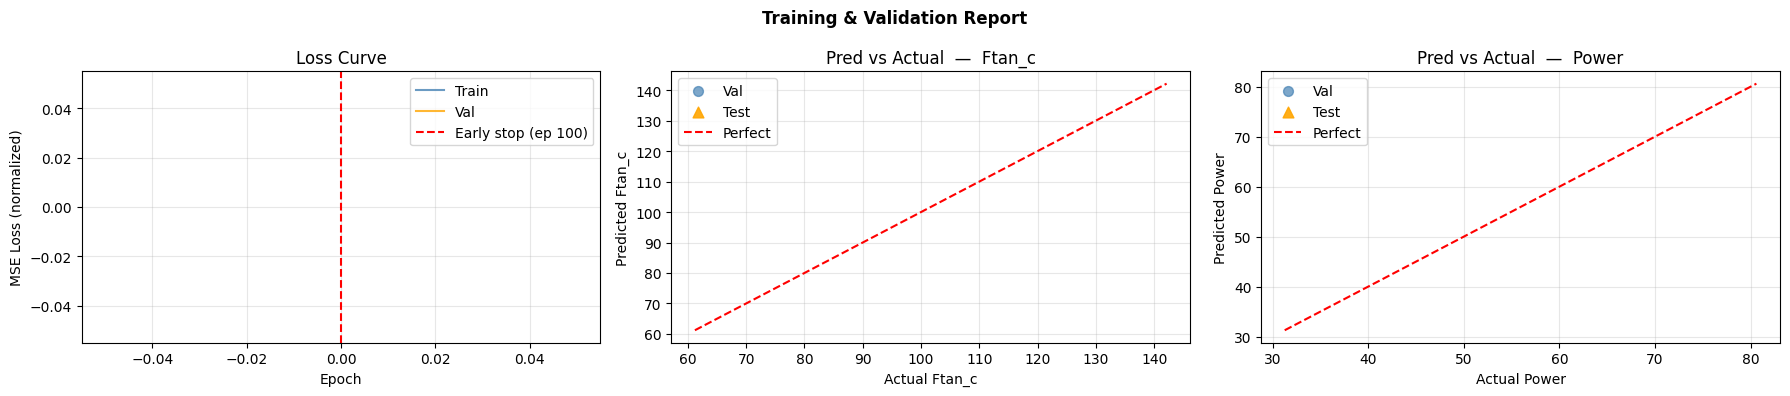

  Residuals
  ----------------------------------------------------------
      Output |   Set |     Bias |      Std |  Max Err
  ----------------------------------------------------------
      Ftan_c |   Val |     +nan |      nan |      nan
      Ftan_c |  Test |     +nan |      nan |      nan
       Power |   Val |     +nan |      nan |      nan
       Power |  Test |     +nan |      nan |      nan
  ----------------------------------------------------------


In [145]:
#Plotting via AI


fig, axes = plt.subplots(1, n_output + 1, figsize=(6*(n_output+1), 4))
fig.suptitle('Training & Validation Report', fontweight='bold')

axes[0].plot(train_loss_hist, label='Train', color='steelblue', alpha=0.8)
axes[0].plot(val_loss_hist,   label='Val',   color='orange',    alpha=0.8)
axes[0].axvline(stopped_epoch - patience, color='red', linestyle='--',
                label=f'Early stop (ep {stopped_epoch})')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss (normalized)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


for i, col in enumerate(target_col):
    ax = axes[i + 1]
    ax.scatter(y_true_val_w[:, i], y_pred_val_w[:, i],
               alpha=0.7, color='steelblue', s=50, label='Val')
    ax.scatter(y_true_te_w[:,  i], y_pred_te_w[:,  i],
               alpha=0.9, color='orange',    s=60, label='Test', marker='^')
    lo = min(y_true_val_w[:, i].min(), y_true_te_w[:, i].min()) - 1
    hi = max(y_true_val_w[:, i].max(), y_true_te_w[:, i].max()) + 1
    ax.plot([lo, hi], [lo, hi], 'r--', label='Perfect')
    ax.set_title(f'Pred vs Actual  —  {col}')
    ax.set_xlabel(f'Actual {col}')
    ax.set_ylabel(f'Predicted {col}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('validation_report.png', dpi=150, bbox_inches='tight')
plt.show()

print('  Residuals')
print('  ' + '-' * 58)
print(f'  {"Output":>10} | {"Set":>5} | {"Bias":>8} | {"Std":>8} | {"Max Err":>8}')
print('  ' + '-' * 58)
for i, col in enumerate(target_col):
    for label, y_p, y_t in [
        ('Val',  y_pred_val_w, y_true_val_w),
        ('Test', y_pred_te_w,  y_true_te_w),
    ]:
        err = y_p[:, i] - y_t[:, i]
        print(f'  {col:>10} | {label:>5} | {err.mean():>+8.4f} | '
              f'{err.std():>8.4f} | {np.abs(err).max():>8.4f}')
print('  ' + '-' * 58)


In [146]:
# Check correlation between targets
print(f"Ftan_c vs Power correlation: {torch.corrcoef(y.T)[0,1]:.4f}")

# Check what the val/test ranges look like per target
for col_i, col in enumerate(target_col):
    print(f"\n{col}")
    print(f"  Train : [{y[train_idx,col_i].min():.2f}, {y[train_idx,col_i].max():.2f}]")
    print(f"  Val   : [{y[val_idx,col_i].min():.2f}, {y[val_idx,col_i].max():.2f}]")
    print(f"  Test  : [{y[test_idx,col_i].min():.2f}, {y[test_idx,col_i].max():.2f}]")

Ftan_c vs Power correlation: 0.6940

Ftan_c
  Train : [52.46, 140.19]
  Val   : [62.20, 141.13]
  Test  : [87.55, 138.74]

Power
  Train : [10.77, 67.43]
  Val   : [32.27, 71.79]
  Test  : [36.82, 79.60]


In [147]:
# AI Wrote the following:

# ── Auto-read run number from existing log ────────────────────────────────────
log_file   = 'experiment_log.csv'
run_number = 0
if os.path.isfile(log_file):
    with open(log_file, 'r') as f:
        run_number = sum(1 for line in f) - 1   # subtract header row

# ── Auto-detect dropout from model ───────────────────────────────────────────
dropout_val = 0.0
for module in model.modules():
    if isinstance(module, nn.Dropout):
        dropout_val = module.p
        break

# ── Auto-detect block structure from model ────────────────────────────────────
block_layers = [type(m).__name__ for m in model.block1]
block_str    = ' -> '.join(block_layers)

# ── Auto-read all configuration from live variables ──────────────────────────
run_config = {
    'run_number'   : run_number + 1,
    'timestamp'    : datetime.now().strftime('%Y-%m-%d %H:%M'),
    # Model
    'block'        : block_str,
    'n_params'     : sum(p.numel() for p in model.parameters()),
    'dropout'      : dropout_val,
    # Physics
    'lambda_pinn'  : Lambda,
    'CHECK'        : str(CHECK),
    # Training
    'epochs_max'   : epochs,
    'stopped_epoch': stopped_epoch,
    'best_val_loss': round(best_val_loss, 6),
    'patience'     : patience,
    'batch_size'   : batch_size,
    'alpha_mixup'  : 0.4,
    # Data
    'n_outputs'    : n_output,
    'seed'         : seed,
    'n_total'      : len(x),
    'n_train'      : len(train_idx),
    'n_val'        : len(val_idx),
    'n_test'       : len(test_idx),
    'pct_train'    : round(len(train_idx) / len(x) * 100, 1),
    'pct_val'      : round(len(val_idx)   / len(x) * 100, 1),
    'pct_test'     : round(len(test_idx)  / len(x) * 100, 1),
}

# ── Auto-collect metrics from results ─────────────────────────────────────────
run_metrics = {}
for col in target_col:
    for split, results in [('val', val_results), ('test', test_results)]:
        run_metrics[f'{col}_{split}_mae']  = round(results[col]['mae'],  4)
        run_metrics[f'{col}_{split}_rmse'] = round(results[col]['rmse'], 4)
        run_metrics[f'{col}_{split}_r2']   = round(results[col]['r2'],   4)

for col_i, col in enumerate(target_col):
    for split, y_p, y_t in [
        ('val',  y_pred_val_w, y_true_val_w),
        ('test', y_pred_te_w,  y_true_te_w),
    ]:
        err = y_p[:, col_i] - y_t[:, col_i]
        run_metrics[f'{col}_{split}_bias']    = round(float(err.mean()),        4)
        run_metrics[f'{col}_{split}_std']     = round(float(err.std()),         4)
        run_metrics[f'{col}_{split}_max_err'] = round(float(np.abs(err).max()), 4)

# ── Merge and write to CSV ────────────────────────────────────────────────────
row        = {**run_config, **run_metrics}
file_exists = os.path.isfile(log_file)

with open(log_file, 'a', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=row.keys())
    if not file_exists:
        writer.writeheader()   # header written once only
    writer.writerow(row)

# ── Print summary ─────────────────────────────────────────────────────────────
print('=' * 62)
print(f'  Run {run_config["run_number"]} logged -> {log_file}')
print('=' * 62)
print(f'  Block      : {block_str}')
print(f'  Dropout    : {dropout_val}')
print(f'  Lambda     : {Lambda}')
print(f'  Physics Formula      : {CHECK}')
print(f'  Parameters : {run_config["n_params"]}')
print(f'  Seed       : {seed}')
print(f'  Outputs    : {n_output}  {target_col}')
print(f'  Split      : {run_config["pct_train"]}% train '
      f'/ {run_config["pct_val"]}% val '
      f'/ {run_config["pct_test"]}% test '
      f'({run_config["n_train"]} / {run_config["n_val"]} / {run_config["n_test"]} samples)')
print(f'  Stopped    : epoch {stopped_epoch} / {epochs}')
print(f'  Best val   : {best_val_loss:.6f}')
print('-' * 62)
print(f'  {"Output":>10} | {"Val MAE":>8} | {"Val R2":>7} | '
      f'{"Test MAE":>9} | {"Test R2":>8} | {"Test Bias":>10} | {"Test Std":>9}')
print(f'  {"-"*80}')
for col in target_col:
    print(f'  {col:>10} | '
          f'{run_metrics[f"{col}_val_mae"]:>8.4f} | '
          f'{run_metrics[f"{col}_val_r2"]:>7.4f} | '
          f'{run_metrics[f"{col}_test_mae"]:>9.4f} | '
          f'{run_metrics[f"{col}_test_r2"]:>8.4f} | '
          f'{run_metrics[f"{col}_test_bias"]:>+10.4f} | '
          f'{run_metrics[f"{col}_test_std"]:>9.4f}')
print('=' * 62)
print(f'  Total runs logged : {run_config["run_number"]}')
print('=' * 62)


  Run 66 logged -> experiment_log.csv
  Block      : Linear -> LayerNorm -> Sigmoid -> Dropout
  Dropout    : 0.0
  Lambda     : 0.5
  Physics Formula      : ['Torque']
  Parameters : 21794
  Seed       : 42
  Outputs    : 2  ['Ftan_c', 'Power']
  Split      : 69.0% train / 18.0% val / 13.0% test (69 / 18 / 13 samples)
  Stopped    : epoch 100 / 700
  Best val   : inf
--------------------------------------------------------------
      Output |  Val MAE |  Val R2 |  Test MAE |  Test R2 |  Test Bias |  Test Std
  --------------------------------------------------------------------------------
      Ftan_c |      nan |     nan |       nan |      nan |       +nan |       nan
       Power |      nan |     nan |       nan |      nan |       +nan |       nan
  Total runs logged : 66
